# MultiClass Benchmarking

#### Set Up

In [22]:
%pip install pandas_ta_classic
%pip install --upgrade pandas_ta_classic
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import numpy as np
import site
import os

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    precision_score, recall_score, f1_score, fbeta_score, matthews_corrcoef,
    mean_squared_error, mean_absolute_error, r2_score, confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from contextlib import nullcontext

import scipy

import random

import matplotlib.pyplot as plt

from unicodedata import bidirectional


In [25]:
def set_global_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seeds(42)

#### Confusion Matrix 

In [26]:
def compute_confusion(y_true, y_pred, labels=None, normalize=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    return cm

def plot_confusion(cm, labels, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(5,4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, values_format=".2f" if cm.dtype.kind=='f' else "d", cmap='Blues', colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    
def aggregate_confusions(results_df, problem_type):
    matrices = results_df['confusion_matrix'].dropna().apply(np.array)
    if matrices.empty:
        return None, None
    agg = np.sum(np.stack(matrices.values, axis=0), axis=0)
    labels = [0,1] if problem_type == 'classification' else list(range(6))
    return agg, labels


### Utility Classes and Functions

In [27]:
# collect logits for any loader (no labels) 
@torch.no_grad()
def collect_logits(model, loader, device):
    model.eval()
    chunks = []
    for xb, _ in loader:
        xb = xb.to(device)
        z  = model(xb)           # [B, K-1]
        chunks.append(z.detach().cpu())
    return torch.cat(chunks, dim=0)   # [N, K-1]

# learn per-threshold taus on VAL (maximize macro-F1 over ordinal-decoded labels) 
def find_taus_per_threshold(Z_val, y_val_idx, grid=np.linspace(start=0, stop=1, num=100)):
    """
    Z_val: torch/numpy [N, K-1] logits from ordinal head on VAL
    y_val_idx: numpy int [N] class indices 0..K-1
    Returns: taus np.float32 [K-1]
    """
    if isinstance(Z_val, torch.Tensor):
        Z_val = Z_val.numpy()
    P_val = 1.0 / (1.0 + np.exp(-Z_val))  # sigmoid -> P(y>k)

    # monotone repair for each sample: enforce P_k >= P_{k+1}
    P_rep = monotone_repair_numpy(P_val)

    K_1 = P_rep.shape[1]
    best_taus = np.full(K_1, 0.5, dtype=np.float32)

    # simple independent sweep per head, decode with all taus applied
    for k in range(K_1):
        best_f1, best_tau = -1.0, 0.5
        for tau in grid:
            y_hat = decode_ordinal_with_taus(P_rep, taus_override={k: tau})
            f1 = f1_score(y_val_idx, y_hat, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1, best_tau = f1, tau
        best_taus[k] = best_tau
    return best_taus

# mnotone repair: cumulative max from right to left 
def monotone_repair_numpy(P):
    """
    P: [N, K-1] with P[:,k] = P(y>k)
    Ensures P[:,k] >= P[:,k+1] for all k by cumulative max from right.
    """
    P = np.asarray(P).copy()
    for k in range(P.shape[1] - 2, -1, -1):
        P[:, k] = np.maximum(P[:, k], P[:, k+1])
    return P


# decode class indices from ordinal probabilities + per-head taus 
def decode_ordinal_with_taus(P_rep, taus=None, taus_override=None):
    """
    P_rep: [N, K-1] repaired cumulative probs (numpy)
    taus: np.array [K-1] default thresholds; optional
    taus_override: dict {k: tau_k} to try alternative per-head tau during search
    Returns y_hat: np.int64 [N] in 0..K-1
    """
    N, K_1 = P_rep.shape
    if taus is None:
        taus = np.full(K_1, 0.5, dtype=np.float32)
    if taus_override:
        taus = taus.copy()
        for k, v in taus_override.items():
            taus[k] = v

    # class = number of thresholds surpassed
    comp = (P_rep >= taus.reshape(1, -1)).astype(np.int32)  # [N, K-1]
    y_hat = comp.sum(axis=1).astype(np.int64)
    return y_hat  # 0..K-1

# from ordinal (cumulative) probs to class probs, then expected class
def ordinal_to_class_probs(P_rep):
    """
    P_rep: [N, K-1] repaired P(y>k)
    Returns: Pc [N, K] with Pc[:,c] = P(y=c)
    """
    N, K_1 = P_rep.shape
    K = K_1 + 1
    Pc = np.empty((N, K), dtype=np.float32)
    # P(y=0) = 1 - P(y>0?)
    Pc[:, 0] = 1.0 - P_rep[:, 0]
    for c in range(1, K-1):
        Pc[:, c] = np.clip(P_rep[:, c-1] - P_rep[:, c], 0.0, 1.0)
    Pc[:, K-1] = P_rep[:, K_1-1]
    # small numerical cleanup
    s = Pc.sum(axis=1, keepdims=True)
    Pc = Pc / np.maximum(s, 1e-8)
    return Pc


In [28]:
# Temperature + Balanced-τ tuning
def _class_dist(y_hat, K):
    hist = np.bincount(y_hat, minlength=K).astype(np.float32)
    return hist / max(1, y_hat.size)

def _balance_penalty(p_hat, p_target, norm="l1"):
    if norm == "l1":
        return float(np.abs(p_hat - p_target).sum())
    elif norm == "l2":
        return float(np.sqrt(((p_hat - p_target) ** 2).sum()))
    else:
        return float(np.abs(p_hat - p_target).sum())

def _decode_with_vector_taus(P_rep, taus_vec):
    comp = (P_rep >= taus_vec.reshape(1, -1)).astype(np.int32)  # [N, K-1]
    return comp.sum(axis=1).astype(np.int64)

def tune_temperature_and_taus(
    Z_val,                   # torch or np: [N, K-1] logits
    y_val_idx,               # np int [N] in 0..K-1
    K,                       # number of classes
    T_grid=np.linspace(0.6, 2.0, 15),
    tau_grid=np.linspace(0.2, 0.8, 31),
    lambda_balance=0.05,     # strength of balance penalty
    target_priors="uniform", # "uniform" or np.array(K,)
    coord_rounds=2           # coordinate-ascent passes over heads
):
    """
    Learns a single temperature T and per-head taus (K-1) by maximizing
    macro-F1 minus a small penalty on deviation of predicted class prior
    from a target distribution (to reduce skew).
    """
    if isinstance(Z_val, torch.Tensor):
        Z_val = Z_val.detach().cpu().numpy()

    N, K_1 = Z_val.shape
    assert K_1 == K - 1

    # choose target priors
    if isinstance(target_priors, str) and target_priors == "uniform":
        p_target = np.ones(K, dtype=np.float32) / K
    else:
        p_target = np.asarray(target_priors, dtype=np.float32)
        p_target = p_target / p_target.sum()

    best = {"score": -1e9, "T": 1.0, "taus": np.full(K_1, 0.5, np.float32)}

    # outer loop over temperature
    for T in T_grid:
        P_cum = 1.0 / (1.0 + np.exp(-(Z_val / T)))   # sigmoid(logits / T)
        P_rep = monotone_repair_numpy(P_cum)         # enforce monotonicity

        # init taus (start from 0.5)
        taus = np.full(K_1, 0.5, dtype=np.float32)

        # coordinate-ascent over thresholds
        for _ in range(coord_rounds):
            for k in range(K_1):
                best_k = (taus[k], -1e9)
                for tau in tau_grid:
                    taus_try = taus.copy()
                    taus_try[k] = tau
                    y_hat = _decode_with_vector_taus(P_rep, taus_try)  # 0..K-1
                    f1 = f1_score(y_val_idx, y_hat, average='macro', zero_division=0)
                    p_hat = _class_dist(y_hat, K)
                    score = f1 - lambda_balance * _balance_penalty(p_hat, p_target, norm="l1")
                    if score > best_k[1]:
                        best_k = (tau, score)
                taus[k] = best_k[0]

        # score full set after coord-ascent
        y_hat = _decode_with_vector_taus(P_rep, taus)
        f1 = f1_score(y_val_idx, y_hat, average='macro', zero_division=0)
        p_hat = _class_dist(y_hat, K)
        score = f1 - lambda_balance * _balance_penalty(p_hat, p_target, norm="l1")

        if score > best["score"]:
            best.update({"score": score, "T": float(T), "taus": taus.astype(np.float32)})

    return best["T"], best["taus"]


In [29]:
# Datasets
class OrdinalSequenceDataset(Dataset):
    def __init__(self, X, T):  # T: float32 matrix [N, K-1] with 0/1
        self.X = torch.tensor(X, dtype=torch.float32)
        self.T = torch.tensor(T, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.T[i]

def make_cumulative_targets(y_int, K):
    y = y_int.reshape(-1, 1)
    ks = np.arange(K-1).reshape(1, -1)
    return (y > ks).astype(np.float32)   # [N, K-1]

def decode_ordinal(probs, thr=0.5):
    return (probs >= thr).sum(axis=1)    # [N] in 0..K-1


In [30]:
class OrdinalHeadCORN(nn.Module):
    def __init__(self, in_dim, K):
        super().__init__()
        self.fc = nn.Linear(in_dim, K-1)   # independent thresholds

    def forward(self, h):                  # h: [B, H]
        return self.fc(h)                  # logits: [B, K-1]


class OrdinalHeadCORAL(nn.Module):
    def __init__(self, in_dim, K):
        super().__init__()
        self.w = nn.Linear(in_dim, 1, bias=False)   # shared direction
        # unconstrained params → cumulative biases ensure b1<=b2<=... via cumsum of positives
        self._beta = nn.Parameter(torch.zeros(K-1)) # unconstrained
        self.softplus = nn.Softplus()

    def forward(self, h):
        base = self.w(h)                  # [B,1]
        deltas = self.softplus(self._beta)  # ≥0
        b = torch.cumsum(deltas, dim=0)     # monotone biases [K-1]
        return base - b                     # broadcast to [B,K-1]



In [31]:
# Models
class RNNHead(nn.Module):

    def __init__(self, input_size, rnn_type='LSTM', bidirectional=False, problem_type='multiclass', n_classes=6, ordinal_head='coral',
                 hidden1=128, hidden2=64, num_layers=2, inter_rnn_drop=0.2, dropout=0.3):
        super().__init__()
        self.problem_type = problem_type
        self.bidirectional = bidirectional
        self.rnn_type = rnn_type.upper()
        self.n_classes = n_classes
        self.ordinal_head = ordinal_head
        self.num_layers = int(num_layers)
        self.hidden1 = int(hidden1)
        self.hidden2 = int(hidden2)

        if self.num_layers not in (1, 2):
            raise ValueError("num_layers must be 1 or 2")

        rnn_cls = {'LSTM': nn.LSTM, 'GRU': nn.GRU}[('GRU' if 'GRU' in self.rnn_type else 'LSTM')]

        self.rnn1 = rnn_cls(
            input_size=input_size, hidden_size=self.hidden1, num_layers=1,
            batch_first=True, dropout=0.0, bidirectional=bidirectional
        )

        self.inter_rnn_drop = nn.Dropout(float(inter_rnn_drop))

        self.rnn2 = None
        if self.num_layers == 2:
            self.rnn2 = rnn_cls(
                input_size=self.hidden1*(2 if bidirectional else 1), hidden_size=self.hidden2, num_layers=1,
                batch_first=True, dropout=0.0, bidirectional=bidirectional
            )
            feat_dim = self.hidden2*(2 if bidirectional else 1)
        else:
            feat_dim = self.hidden1*(2 if bidirectional else 1)

        self.bn = nn.BatchNorm1d(feat_dim)
        self.fc = nn.Linear(feat_dim, 32)
        self.drop = nn.Dropout(float(dropout))
        if self.ordinal_head == 'coral':
            self.out = OrdinalHeadCORAL(32, self.n_classes)
        else:
            self.out = OrdinalHeadCORN(32, self.n_classes)

    def forward(self, x):
        # x: [B, T, F]
        out, _ = self.rnn1(x)
        if self.num_layers == 2:
            out = self.inter_rnn_drop(out)   # inter-layer dropout (sequence-wise)
            out, _ = self.rnn2(out)
        # take last timestep: [B, T, H] -> [B, H]
        out = out[:, -1, :]
        out = self.bn(out)
        out = F.relu(self.fc(out))
        out = self.drop(out)
        out = self.out(out)  # shape [B, 1] or [B, output_dim]
        return out  # regression: raw; classification: logits


def build_model(input_shape, model_type='LSTM', problem_type='multiclass', n_classes=6, ordinal_head=None,
                hidden1=128, hidden2=64, num_layers=2, inter_rnn_drop=0.2, dropout=0.3):
    seq_len, n_features = input_shape
    model_type = model_type.upper()
    kwargs = dict(
        problem_type=problem_type,
        n_classes=n_classes,
        ordinal_head=ordinal_head,
        hidden1=hidden1,
        hidden2=hidden2,
        num_layers=num_layers,
        inter_rnn_drop=inter_rnn_drop,
        dropout=dropout,
    )
    if model_type == 'LSTM':
        return RNNHead(n_features, rnn_type='LSTM', bidirectional=False, **kwargs)
    elif model_type == 'BILSTM':
        return RNNHead(n_features, rnn_type='LSTM', bidirectional=True, **kwargs)
    elif model_type == 'GRU':
        return RNNHead(n_features, rnn_type='GRU', bidirectional=False, **kwargs)
    elif model_type == 'BIGRU':
        return RNNHead(n_features, rnn_type='GRU', bidirectional=True, **kwargs)
    else:
        raise ValueError("Model type must be one of: ['LSTM','BiLSTM','GRU','BiGRU']")
class EarlyStopper:
    def __init__(self, patience=15, min_delta=0.0, restore_best=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best = restore_best
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        improved = (self.best_loss - val_loss) > self.min_delta
        if improved:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best:
                # Deep copy state dict
                self.best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.restore_best and self.best_state is not None:
            model.load_state_dict(self.best_state)


### Bucket Scheme

In [32]:
BUCKET_BINS   = [-float('inf'), -0.02, -0.005, 0.00, 0.005, 0.02, float('inf')]
BUCKET_LABELS = [0, 1, 2, 3, 4, 5]   
BUCKET_LABEL_NAMES = {
    0: "≤ -2%",
    1: "(-2,-0.5]%",
    2: "(-0.5,0]%",
    3: "(0,0.5]%",
    4: "(0.5,2]%",
    5: "≥ 2%"
}

display_labels = [BUCKET_LABEL_NAMES[i] for i in BUCKET_LABELS]

def pct_return(series, h):
    return series.shift(-h) / series - 1.0

def bucketise_returns(ret_series):
    return pd.cut(ret_series, bins=BUCKET_BINS, labels=BUCKET_LABELS, include_lowest=True, right=True).astype('Int64')

In [33]:
def safe_quantile_edges(x, n_classes=6):
    qs = np.linspace(0, 1, n_classes+1)
    edges = np.quantile(x, qs)
    for i in range(1, len(edges)):
        if edges[i] <= edges[i-1]:
            edges[i] = np.nextafter(edges[i-1], np.inf)
    return edges  # length n_classes+1

def bucketize_with_edges(x, edges):
    inner = edges[1:-1]
    labels = np.digitize(x, inner, right=True)
    return labels.astype(int)  # 0..C-1

## Stock Prediction Pipeline

In [ ]:
import traceback


class StockPredictionPipeline:
    def __init__(self, df, feature_columns, model_type='LSTM', sequence_length=30, problem_type='multiclass', horizon_steps=1, n_classes=6, ordinal_head='coral',
                 hidden1=128, hidden2=64, num_layers=2, inter_rnn_drop=0.2, dropout=0.3,
                 batch_size=32, learning_rate=1e-3, weight_decay=1e-5, lr_patience=7, lr_factor=0.5,
                 early_stopping_patience=15, max_epochs=100, huber_delta=1.0, early_stopping_min_delta=0.0, trial=None,
                 t_min=0.6, t_max=2.5, t_steps=15, tau_min=0.2, tau_max=0.8, tau_steps=31,
                 lambda_balance=0.05, coord_rounds=4):
        self.df = df.copy()
        self.feature_columns = feature_columns
        self.model_type = model_type
        self.sequence_length = sequence_length
        self.problem_type = problem_type
        self.horizon_steps = horizon_steps
        self.n_classes = n_classes
        self.ordinal_head = ordinal_head
        self.hidden1 = hidden1
        self.hidden2 = hidden2
        self.num_layers = num_layers
        self.inter_rnn_drop = inter_rnn_drop
        self.dropout = dropout
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.lr_patience = lr_patience
        self.lr_factor = lr_factor
        self.early_stopping_patience = early_stopping_patience
        self.max_epochs = max_epochs
        self.huber_delta = huber_delta
        self.early_stopping_min_delta = early_stopping_min_delta
        self.t_min = t_min
        self.t_max = t_max
        self.t_steps = t_steps
        self.tau_min = tau_min
        self.tau_max = tau_max
        self.tau_steps = tau_steps
        self.lambda_balance = lambda_balance
        self.coord_rounds = coord_rounds
        self.trial = trial
        self.results = []
        self.loss_curves = []
        self._validate_inputs()

        # Device & precision
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.mixed_precision = torch.cuda.is_available()

        print(f"Pipeline initialized for a '{self.problem_type}' problem "
              f"with horizon {self.horizon_steps} steps. Device: {self.device}")

    def _validate_inputs(self):
        missing_cols = [col for col in self.feature_columns if col not in self.df.columns]
        if missing_cols:
            raise ValueError(f"Missing feature columns: {missing_cols}")

        if 'close' not in self.df.columns and 'close_price' not in self.df.columns:
            raise ValueError("No 'close' or 'close_price' column found in data")

        valid_models = ['LSTM', 'BiLSTM', 'GRU', 'BiGRU']
        if self.model_type not in valid_models:
            raise ValueError(f"Model type must be one of: {valid_models}")

        if self.problem_type not in ['multiclass']:
            raise ValueError("Problem type must be 'multiclass'")

    def create_target_variable(self, company_data):
        company_data = company_data.copy()
        price_col = 'close' if 'close' in company_data.columns else 'close_price'
        if 'date' in company_data.columns:
            company_data = company_data.sort_values('date')
            
        h = self.horizon_steps

        company_data['target_regression'] = (
            np.log(company_data[price_col].shift(-h)) - np.log(company_data[price_col])
        )
        company_data['target_direction'] = (company_data['target_regression'] > 0).astype(int)        

        company_data['ret_h'] = pct_return(company_data[price_col], h)
        subset = ['ret_h']
        company_data = company_data.dropna(subset=subset)        
            
        return company_data

    def create_sequences(self, features, *targets):
        X = []
        y_sequences = [[] for _ in targets]
        for i in range(self.sequence_length, len(features)):
            X.append(features[i-self.sequence_length:i])
            for j, target in enumerate(targets):
                y_sequences[j].append(target[i])
        return (np.array(X),) + tuple(np.array(y) for y in y_sequences)

    def _train_one_epoch_multiclass(self, model, loader, optimizer, scaler, *, pos_weight=None):
        model.train()
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(self.device)             # [B,T,F]
            yb = yb.to(self.device)             # ordinal: [B,K-1] float
            optimizer.zero_grad(set_to_none=True)
            ctx = torch.amp.autocast('cuda') if self.mixed_precision else nullcontext()
            with ctx:
                logits = model(xb)              # [B, K-1] for ordinal
               
                # BCE with per-head pos_weight
                # compute weighted BCE per column, then mean over columns
                bces = []
                for k in range(logits.shape[1]):
                    w = None if pos_weight is None else pos_weight[k]
                    bce_k = F.binary_cross_entropy_with_logits(
                        logits[:, k], yb[:, k], pos_weight=w
                    )
                    bces.append(bce_k)
                loss = torch.stack(bces).mean()

            if self.mixed_precision:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total += float(loss.item()) * xb.size(0)
        return total / len(loader.dataset)

    @torch.no_grad()
    def _eval_one_epoch_multiclass(self, model, loader, pos_weight=None):
        model.eval()
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(self.device)
            yb = yb.to(self.device)
            logits = model(xb)
            bces = []
            for k in range(logits.shape[1]):
                w = None if pos_weight is None else pos_weight[k]
                bce_k = F.binary_cross_entropy_with_logits(
                    logits[:, k], yb[:, k], pos_weight=w
                )
                bces.append(bce_k)
            loss = torch.stack(bces).mean()
            total += float(loss.item()) * xb.size(0)
        return total / len(loader.dataset)

    @torch.no_grad()
    def _predict(self, model, loader):
        model.eval()
        outs = []
        for xb, _ in loader:
            xb = xb.to(self.device)

            logits = model(xb).detach().cpu().numpy()
            outs.append(logits)
            
        return np.concatenate(outs, axis=0)

    # build_model
    def build_model(self, input_shape):
        return build_model(
            input_shape,
            model_type=self.model_type,
            problem_type=self.problem_type,
            n_classes=self.n_classes,
            ordinal_head=self.ordinal_head,
            hidden1=self.hidden1,
            hidden2=self.hidden2,
            num_layers=self.num_layers,
            inter_rnn_drop=self.inter_rnn_drop,
            dropout=self.dropout
        ).to(self.device)


    def process_company(self, company_name, company_data, sector):
        print(f"Processing {company_name} ({sector})...")
        try:
            company_data = company_data.copy()
            if 'date' not in company_data.columns:
                print(f"Missing date column for {company_name}. Skipping...")
                return None
            company_data['date'] = pd.to_datetime(company_data['date'], errors='coerce')
            company_data = company_data.dropna(subset=['date'])
            if company_data.empty:
                print(f"No valid dates for {company_name}. Skipping...")
                return None

            company_data = self.create_target_variable(company_data)

            # Min samples requirement (aligned with Benchmarking.ipynb)
            min_samples = self.sequence_length + self.horizon_steps + 60
            if len(company_data) < min_samples:
                print(f"Insufficient data for {company_name} ({len(company_data)} < {min_samples}). Skipping...")
                return None

            # missing features check
            if company_data[self.feature_columns].isnull().any().any():
                print(f"Missing values in features for {company_name}. Skipping...")
                return None

            # build sequences
            features    = company_data[self.feature_columns].values
            target_reg  = company_data['target_regression'].values
            target_dir  = company_data['target_direction'].values
            X_raw, y_reg, y_dir = self.create_sequences(features, target_reg, target_dir)

            # Date-based split (fixed ranges)
            seq_end_dates = pd.to_datetime(company_data['date'].values[self.sequence_length:], errors='coerce')
            valid_dates_mask = ~pd.isna(seq_end_dates)
            if not valid_dates_mask.any():
                print(f"No valid sequence dates for {company_name}. Skipping...")
                return None

            # Apply valid date mask to sequences and targets
            X_raw = X_raw[valid_dates_mask]
            y_reg = y_reg[valid_dates_mask]
            y_dir = y_dir[valid_dates_mask]
            seq_end_dates = seq_end_dates[valid_dates_mask]

            train_start = pd.Timestamp('2014-01-01')
            train_end = pd.Timestamp('2015-08-01')
            val_end = pd.Timestamp('2015-10-01')
            test_end = pd.Timestamp('2016-01-01')

            train_mask = (seq_end_dates >= train_start) & (seq_end_dates < train_end)
            val_mask   = (seq_end_dates >= train_end) & (seq_end_dates < val_end)
            test_mask  = (seq_end_dates >= val_end) & (seq_end_dates < test_end)

            train_idx = np.where(train_mask)[0]
            val_idx   = np.where(val_mask)[0]
            test_idx  = np.where(test_mask)[0]

            if len(train_idx) == 0:
                print(f"No training data in range for {company_name}. Skipping...")
                return None
            if len(val_idx) == 0:
                print(f"No validation data in range for {company_name}. Skipping...")
                return None
            if len(test_idx) == 0:
                print(f"No test data in range for {company_name}. Skipping...")
                return None

            X_train_raw, X_val_raw, X_test_raw = X_raw[train_idx], X_raw[val_idx], X_raw[test_idx]

            F = X_raw.shape[-1]
            feat_scaler = StandardScaler()
            X_train = feat_scaler.fit_transform(X_train_raw.reshape(-1, F)).reshape(X_train_raw.shape)
            X_val   = feat_scaler.transform(X_val_raw.reshape(-1, F)).reshape(X_val_raw.shape)
            X_test  = feat_scaler.transform(X_test_raw.reshape(-1, F)).reshape(X_test_raw.shape)

            # ordinal (multiclass) with fixed bucketing
            if self.problem_type != 'multiclass':
                raise ValueError("This drop-in process_company is for 'multiclass' (ordinal) only.")

            # align returns with sequences
            if 'ret_h' not in company_data.columns:
                raise RuntimeError("Expected 'ret_h' for ordinal but not found. create_target_variable must set it.")
            ret_full     = company_data['ret_h'].values
            ret_seq_full = ret_full[self.sequence_length:]
            ret_seq_full = ret_seq_full[valid_dates_mask]

            # fixed edges/labels
            K      = int(self.n_classes)
            edges  = np.asarray(BUCKET_BINS, dtype=float)
            assert len(edges) == K + 1, "BUCKET_BINS must have K+1 edges."
            label_names = [BUCKET_LABEL_NAMES[i] for i in range(K)]

            # bucketize all sequence-aligned returns using fixed edges
            y_bucket_full = pd.cut(
                ret_seq_full, bins=edges, labels=list(range(K)),
                include_lowest=True, right=True
            ).astype('Int64').to_numpy().astype(np.int64)

            # split to train/val/test
            y_train = y_bucket_full[train_idx]
            y_val   = y_bucket_full[val_idx]
            y_test  = y_bucket_full[test_idx]

            # hard cumulative targets (ordinal)
            T_train = make_cumulative_targets(y_train, K)
            T_val   = make_cumulative_targets(y_val,   K)
            T_test  = make_cumulative_targets(y_test,  K)

            # datasets & loaders
            train_ds = OrdinalSequenceDataset(X_train, T_train)
            val_ds   = OrdinalSequenceDataset(X_val,   T_val)
            test_ds  = OrdinalSequenceDataset(X_test,  T_test)

            train_loader = DataLoader(train_ds, batch_size=self.batch_size, shuffle=False, drop_last=False, num_workers=0)
            val_loader   = DataLoader(val_ds,   batch_size=self.batch_size, shuffle=False, drop_last=False, num_workers=0)
            test_loader  = DataLoader(test_ds,  batch_size=self.batch_size, shuffle=False, drop_last=False, num_workers=0)

            # model 
            model = self.build_model((self.sequence_length, len(self.feature_columns)))

            # loss weights (per threshold) from TRAIN positives
            pos_rate = T_train.mean(axis=0)
            pos_weight = (1.0 - pos_rate) / np.clip(pos_rate, 1e-6, 1.0)
            mid_cut = (K // 2)
            upper_mask = np.arange(pos_weight.shape[0]) >= max(mid_cut - 1, 0)
            pos_weight[upper_mask] *= 1.5
            pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(self.device)
            assert pos_weight_tensor.shape[0] == (K - 1)

            # optimizer, scheduler, early stopping
            optimizer = Adam(model.parameters(), lr=self.learning_rate, eps=1e-7, weight_decay=self.weight_decay)
            scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=self.lr_factor, patience=self.lr_patience, min_lr=1e-7)
            early_stopper = EarlyStopper(patience=self.early_stopping_patience, min_delta=self.early_stopping_min_delta, restore_best=True)
            scaler = torch.amp.GradScaler('cuda', enabled=self.mixed_precision)

            # train
            max_epochs = self.max_epochs
            epochs_trained = 0
            for epoch in range(1, max_epochs + 1):
                train_loss = self._train_one_epoch_multiclass(model, train_loader, optimizer, scaler, pos_weight=pos_weight_tensor)
                val_loss   = self._eval_one_epoch_multiclass(model, val_loader, pos_weight=pos_weight_tensor)
                scheduler.step(val_loss)
                stop = early_stopper.step(val_loss, model)
                epochs_trained = epoch

                row = {
                    'company': company_name, 'sector': sector,
                    'model_type': self.model_type, 'problem_type': self.problem_type,
                    'sequence_length': self.sequence_length, 'horizon_steps': self.horizon_steps,
                    'epoch': epoch, 'train_loss': float(train_loss), 'val_loss': float(val_loss),
                    'train_samples': len(X_train), 'val_samples': len(X_val), 'test_samples': len(X_test),
                }
                self.loss_curves.append(row)

                if epoch % 10 == 0 or stop:
                    print(f"  Epoch {epoch:03d} - train {train_loss:.5f} | val {val_loss:.5f}")
                if stop:
                    break

            # Restore best weights
            early_stopper.restore(model)

            # calibrate τ on VAL, decode TEST
            Z_val = collect_logits(model, val_loader, self.device)
            T_star, taus = tune_temperature_and_taus(
                Z_val=Z_val,
                y_val_idx=y_val.astype(np.int64),
                K=K,
                T_grid=np.linspace(0.6, 2.5, 15),
                tau_grid=np.linspace(0.2, 0.8, 31),
                lambda_balance=0.05,
                target_priors="uniform",
                coord_rounds=4
            )

            Z_test = collect_logits(model, test_loader, self.device)
            P_cum  = 1.0 / (1.0 + np.exp(-(Z_test.detach().cpu().numpy() / T_star)))
            P_rep  = monotone_repair_numpy(P_cum)

            y_pred_labels = decode_ordinal_with_taus(P_rep, taus=taus)
            y_true_labels = y_test

            labels = list(range(K))
            cm_counts = compute_confusion(y_true_labels, y_pred_labels, labels=labels, normalize=None)
            cm_norm   = compute_confusion(y_true_labels, y_pred_labels, labels=labels, normalize='true')

            micro_acc = (y_true_labels == y_pred_labels).mean()
            macro_f1  = f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)

            # expected returns
            ret_seq_train = ret_seq_full[train_idx].astype(np.float32)
            mu_c = np.array([
                ret_seq_train[y_train == c].mean() if np.any(y_train == c) else 0.0
                for c in range(K)
            ], dtype=np.float32)

            P_class = ordinal_to_class_probs(P_rep)
            expected_ret = (P_class * mu_c[None, :]).sum(axis=1)
            expected_ret_mean = float(expected_ret.mean())

            # binary collapse (for comparability with dir. metrics)
            mid_cut = (K // 2)
            y_true_dir = (y_true_labels >= mid_cut).astype(int)
            y_pred_dir = (y_pred_labels >= mid_cut).astype(int)
            precision = precision_score(y_true_dir, y_pred_dir, zero_division=0)
            recall    = recall_score(y_true_dir, y_pred_dir, zero_division=0)
            f1        = f1_score(y_true_dir, y_pred_dir, zero_division=0)
            mcc       = matthews_corrcoef(y_true_dir, y_pred_dir) if len(np.unique(y_pred_dir)) > 1 else 0.0
            directional_accuracy = (y_true_dir == y_pred_dir).mean()

            result = {
                'company': company_name, 'sector': sector,
                'model_type': self.model_type, 'problem_type': self.problem_type,
                'horizon_steps': self.horizon_steps,
                'macro_f1': macro_f1, 'micro_accuracy': micro_acc,
                'expected_return_mean': expected_ret_mean,
                'mse': np.nan, 'mae': np.nan, 'r2': np.nan,
                'mcc': mcc, 'f1': f1, 'precision': precision, 'recall': recall,
                'directional_accuracy': directional_accuracy,
                'n_samples': int(X_raw.shape[0]),
                'train_samples': int(X_train.shape[0]),
                'val_samples': int(X_val.shape[0]),
                'test_samples': int(X_test.shape[0]),
                'epochs_trained': epochs_trained
            }
            result['confusion_matrix'] = cm_counts.tolist()
            result['confusion_matrix_normalized'] = cm_norm.tolist()
            result['bucket_edges']  = edges.astype(float).tolist()
            result['bucket_labels'] = label_names
            result['taus']          = np.asarray(taus, dtype=float).tolist()

            print(f"  Multiclass -> Micro Acc: {micro_acc:.4f}, Macro F1: {macro_f1:.4f}, Expected Return: {expected_ret_mean:.6f}")

            del model
            torch.cuda.empty_cache()
            return result

        except Exception as e:
            print(f"Error processing {company_name}: {str(e)}")
            traceback.print_exc()
            torch.cuda.empty_cache()
            return None

    def run_pipeline(self):
        company_col = None
        for col_name in ['ticker', 'company', 'symbol']:
            if col_name in self.df.columns:
                company_col = col_name
                break
        if company_col is None:
            company_col = self.df.columns[0]
            print(f"Warning: Using '{company_col}' as company identifier column")

        companies = self.df[company_col].unique()
        print(f"Processing {len(companies)} companies with {self.model_type} model...")
        print(f"Problem type: {self.problem_type}")
        print(f"Sequence length: {self.sequence_length}")
        print(f"Features: {self.feature_columns}")

        successful_companies = 0
        for i, company in enumerate(companies, 1):
            print(f"\n[{i}/{len(companies)}] Processing {company}...")
            company_data = self.df[self.df[company_col] == company].copy()
            sector = company_data['sector'].iloc[0] if 'sector' in company_data.columns else 'Unknown'
            result = self.process_company(company, company_data, sector)
            if result:
                self.results.append(result)
                successful_companies += 1

        print(f"\n{'='*80}")
        print(f"Pipeline completed: {successful_companies}/{len(companies)} companies processed successfully")
        print(f"{'='*80}")

        if self.results:
            self.results_df = pd.DataFrame(self.results)
            return self.results_df
        else:
            print("No companies were processed successfully!")
            return pd.DataFrame()

    def analyze_results(self):
        if not hasattr(self, 'results_df') or self.results_df.empty:
            print("No results to analyze!")
            return None

        df = self.results_df
        analysis = {}

        print("\n" + "="*80)
        print("STOCK PREDICTION PIPELINE RESULTS")
        print("="*80)
        print(f"Model: {self.model_type} | Problem: {self.problem_type}")
        print(f"Companies analyzed: {len(df)}")
        print(f"Average samples per company: {df['n_samples'].mean():.0f}")

        print("\n" + "="*50)
        print("OVERALL PERFORMANCE")
        print("="*50)

        print(f"Micro Accuracy:         {df['micro_accuracy'].mean():.4f} (±{df['micro_accuracy'].std():.4f})")
        print(f"Macro F1 Score:         {df['macro_f1'].mean():.4f} (±{df['macro_f1'].std():.4f})")
        print(f"Directional Accuracy:   {df['directional_accuracy'].mean():.4f} (±{df['directional_accuracy'].std():.4f})")
        print(f"Matthews Correlation:   {df['mcc'].mean():.4f} (±{df['mcc'].std():.4f})")
        print(f"F1 Score:              {df['f1'].mean():.4f} (±{df['f1'].std():.4f})")
        print(f"Precision:             {df['precision'].mean():.4f} (±{df['precision'].std():.4f})")
        print(f"Recall:                {df['recall'].mean():.4f} (±{df['recall'].std():.4f})")
        print(f"Expected Return:        {df['expected_return_mean'].mean():.6f} (±{df['expected_return_mean'].std():.4f})")

        
        print("\n" + "="*50)
        print("TOP 10 BY EXPECTED RETURN (mean)")
        print("="*50)
        top_er = df.nlargest(10, 'expected_return_mean')
        for _, row in top_er.iterrows():
            print(f"{row['company']:<20} | {row['sector']:<15} | "
                    f"E[r]_mean: {row['expected_return_mean']:.4e} | Macro-F1: {row['macro_f1']:.3f}")

        if 'sector' in df.columns and df['sector'].nunique() > 1:
            print("\n" + "="*50)
            print("PERFORMANCE BY SECTOR")
            print("="*50)
            sector_stats = df.groupby('sector').agg({
                'directional_accuracy': ['mean', 'std', 'count'],
                'mcc': ['mean', 'std'],
                'r2': 'mean' if self.problem_type == 'regression' else lambda x: np.nan,
                'mae': 'mean' if self.problem_type == 'regression' else lambda x: np.nan
            }).round(4)
            sector_stats.columns = ['_'.join(col).strip() if col[1] else col[0] for col in sector_stats.columns]
            sector_stats = sector_stats.sort_values('directional_accuracy_mean', ascending=False)
            for sector, row in sector_stats.iterrows():
                print(f"{sector:<20} | Acc: {row['directional_accuracy_mean']:.3f}±{row['directional_accuracy_std']:.3f} | "
                      f"MCC: {row['mcc_mean']:.3f} | Companies: {int(row['directional_accuracy_count'])}")

        print("\n" + "="*50)
        print("TOP 10 PERFORMERS (by Directional Accuracy)")
        print("="*50)
        top_performers = df.nlargest(10, 'directional_accuracy')
        for _, row in top_performers.iterrows():
            print(f"{row['company']:<20} | {row['sector']:<15} | "
                  f"Acc: {row['directional_accuracy']:.3f} | MCC: {row['mcc']:.3f}")

        return analysis

    def save_results(self, results, output_dir='results/benchmarking'):
        if results is not None and not results.empty:
            model_name = self.model_type

            if self.problem_type == 'multiclass':
                out_dir = os.path.join(output_dir, 'multiclass')

            os.makedirs(out_dir, exist_ok=True)

            output_path = os.path.join(out_dir, f"{model_name}.csv")

            results.to_csv(output_path, index=False)
            print(f"Results saved to {output_path}")
        else:
            print("No results to save.")
            
        
            
    def get_loss_curves_df(self):
        if not self.loss_curves:
            print("No loss curves logged yet.")
            return pd.DataFrame()
        return pd.DataFrame(self.loss_curves)

    def save_loss_curves(self, out_path='results/benchmarking/'):
        df = self.get_loss_curves_df()
        if df.empty:
            print("No loss curves to save.")
            return
        else:
            out_path = os.path.join(out_path, 'multiclass', f"{self.model_type}_loss_curves.csv")
            
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        
        df.to_csv(out_path, index=False)
        print(f"Loss curves saved to {out_path}")

    def get_feature_importance_analysis(self):
        print("Feature importance analysis not implemented yet.")
        print("Consider implementing SHAP values or permutation importance for better insights.")
        return None

## Data Preparation

In [35]:
master_df = pd.read_parquet('../data/dataset/ta_nlp_sector.parquet')

In [36]:
master_df.columns

Index(['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'ticker',
       'ema_12', 'ema_26', 'ema_50', 'macd_12_26_9', 'macdh_12_26_9',
       'macds_12_26_9', 'rsi_14', 'stochrsik_14_14_3_3', 'stochrsid_14_14_3_3',
       'atrr_14', 'bb_upper', 'bb_middle', 'bb_lower', 'obv', 'ret_1d',
       'roll_ret_1d', 'roll_ret_5d', 'roll_ret_20d', 'sentiment',
       'emotion_anger', 'emotion_disgust', 'emotion_fear', 'emotion_joy',
       'emotion_neutral', 'emotion_sadness', 'emotion_surprize',
       'emotion_anger_pct', 'emotion_disgust_pct', 'emotion_fear_pct',
       'emotion_joy_pct', 'emotion_neutral_pct', 'emotion_sadness_pct',
       'emotion_surprize_pct', 'positive_emotion', 'negative_emotion',
       'uncertainty_emotion', 'positive_emotion_pct', 'negative_emotion_pct',
       'uncertainty_emotion_pct', 'stance_label', 'finbert_label',
       'stance_score', 'finbert_score', 'finbert_up', 'finbert_down',
       'finbert_neutral', 'sector', 'company_name', 'sector_open

In [37]:
columns_to_check = [
                    'sentiment',
                    
                    'emotion_anger', 'emotion_disgust', 'emotion_fear', 'emotion_joy',
                    'emotion_neutral', 'emotion_sadness', 'emotion_surprize',
                    'emotion_anger_pct', 'emotion_disgust_pct', 'emotion_fear_pct',
                    'emotion_joy_pct', 'emotion_neutral_pct', 'emotion_sadness_pct',
                    'emotion_surprize_pct', 
                    
                    'positive_emotion', 'negative_emotion','uncertainty_emotion', 
                    'positive_emotion_pct', 'negative_emotion_pct','uncertainty_emotion_pct', 
                    
                    'stance_label', 'stance_score', 
                    
                    'finbert_label', 'finbert_score', 'finbert_up', 'finbert_down',
                    'finbert_neutral', 
                    
                    'sector_open_mean', 'sector_high_mean', 'sector_low_mean', 'sector_close_mean',
                    'sector_volume_mean', 'sector_ret_1d', 'sector_ret_5d',
                    'sector_ret_20d', 'sector_range', 'sector_vol_20d', 
                    
                    'ema_12_sector','ema_26_sector', 'ema_50_sector', 'macd_12_26_9_sector',
                    'macdh_12_26_9_sector', 'macds_12_26_9_sector', 'rsi_14_sector',
                    'sector_bb_upper', 'sector_bb_middle', 'sector_bb_lower',
                    'market_close', 'sector_rel_strength', 'sector_dispersion_1d'
                ]

print(f"Initial master_df shape: {master_df.shape}")

master_df = master_df.dropna(subset=columns_to_check)

print(f"After dropping NaNs in selected columns, master_df shape: {master_df.shape}")

master_df.reset_index(drop=True, inplace=True)

display(master_df)

Initial master_df shape: (108592, 79)
After dropping NaNs in selected columns, master_df shape: (104476, 79)


,date,open,high,low,close,adj_close,volume,ticker,ema_12,ema_26,...,macd_12_26_9_sector,macdh_12_26_9_sector,macds_12_26_9_sector,rsi_14_sector,sector_bb_upper,sector_bb_middle,sector_bb_lower,market_close,sector_rel_strength,sector_dispersion_1d
0,2012-11-14,77.928574,78.207146,76.597145,76.697144,69.613815,119292600.0,AAPL,80.708033,84.949698,...,-0.913108,-0.181794,-0.731314,27.619972,63.948320,61.465736,58.983152,1484.350654,-0.003089,0.006800
1,2012-11-15,76.790001,77.071426,74.660004,75.088570,68.153778,197477700.0,AAPL,79.843501,84.219244,...,-0.926239,-0.155940,-0.770299,32.479352,63.646173,61.261193,58.876213,1484.574993,0.002003,0.019838
2,2012-11-16,75.028572,75.714287,72.250000,75.382858,68.420891,316723400.0,AAPL,79.157248,83.564697,...,-0.892113,-0.097452,-0.794662,37.450172,63.236926,61.078872,58.920817,1497.780485,0.010276,0.010265
3,2012-11-19,77.244286,81.071426,77.125717,80.818573,73.354591,205829400.0,AAPL,79.412836,83.361280,...,-0.733193,0.049174,-0.782368,51.350390,63.001827,61.010079,59.018330,1506.128807,0.024682,0.018850
4,2012-11-20,81.701431,81.707146,79.225716,80.129997,72.729614,160688500.0,AAPL,79.523169,83.121926,...,-0.579416,0.162361,-0.741778,53.267164,62.959435,60.996029,59.032623,1508.629302,0.025531,0.007554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104471,2017-08-28,76.900002,76.940002,76.260002,76.470001,76.470001,8229700.0,XOM,77.187452,78.267858,...,-0.111192,0.016355,-0.127548,53.634155,63.049962,61.014300,58.978638,3101.328695,-0.007883,0.005228
104472,2017-08-29,76.209999,76.489998,76.080002,76.449997,76.449997,7060400.0,XOM,77.073998,78.133202,...,-0.067027,0.048417,-0.115443,54.205103,62.862103,60.944450,59.026797,3102.507723,-0.016661,0.002030
104473,2017-08-30,76.239998,76.449997,76.059998,76.099998,76.099998,8218000.0,XOM,76.924151,77.982594,...,-0.037643,0.062240,-0.099883,53.126723,62.639604,60.868750,59.097896,3128.753695,-0.017629,0.004873
104474,2017-08-31,76.269997,76.489998,76.050003,76.330002,76.330002,15641700.0,XOM,76.832744,77.860180,...,0.013408,0.090633,-0.077225,57.342960,62.525437,60.831900,59.138363,3141.201722,-0.008376,0.006185


In [38]:
print(master_df.columns)

Index(['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'ticker',
       'ema_12', 'ema_26', 'ema_50', 'macd_12_26_9', 'macdh_12_26_9',
       'macds_12_26_9', 'rsi_14', 'stochrsik_14_14_3_3', 'stochrsid_14_14_3_3',
       'atrr_14', 'bb_upper', 'bb_middle', 'bb_lower', 'obv', 'ret_1d',
       'roll_ret_1d', 'roll_ret_5d', 'roll_ret_20d', 'sentiment',
       'emotion_anger', 'emotion_disgust', 'emotion_fear', 'emotion_joy',
       'emotion_neutral', 'emotion_sadness', 'emotion_surprize',
       'emotion_anger_pct', 'emotion_disgust_pct', 'emotion_fear_pct',
       'emotion_joy_pct', 'emotion_neutral_pct', 'emotion_sadness_pct',
       'emotion_surprize_pct', 'positive_emotion', 'negative_emotion',
       'uncertainty_emotion', 'positive_emotion_pct', 'negative_emotion_pct',
       'uncertainty_emotion_pct', 'stance_label', 'finbert_label',
       'stance_score', 'finbert_score', 'finbert_up', 'finbert_down',
       'finbert_neutral', 'sector', 'company_name', 'sector_open

In [39]:
feature_columns = [
    'open', 'high', 'low', 'close', 'volume',
    'roll_ret_1d', 'roll_ret_5d', 
    'roll_ret_20d',
    
    'ema_12', 'ema_26', 'ema_50', 'macd_12_26_9', 'macdh_12_26_9',
    'macds_12_26_9', 'rsi_14', 'stochrsik_14_14_3_3', 'stochrsid_14_14_3_3',
    'atrr_14', 'bb_upper', 'bb_middle', 'bb_lower', 'obv',
]

new_indicator_columns = [
    'sentiment',
                    
    'emotion_anger', 'emotion_disgust', 'emotion_fear', 'emotion_joy',
    'emotion_neutral', 'emotion_sadness', 'emotion_surprize',
    'emotion_anger_pct', 'emotion_disgust_pct', 'emotion_fear_pct',
    'emotion_joy_pct', 'emotion_neutral_pct', 'emotion_sadness_pct',
    'emotion_surprize_pct', 
    
    'positive_emotion', 'negative_emotion','uncertainty_emotion', 
    'positive_emotion_pct', 'negative_emotion_pct','uncertainty_emotion_pct', 
    
    'stance_label', 'stance_score', 
    
    'finbert_label', 'finbert_score', 'finbert_up', 'finbert_down',
    'finbert_neutral', 
    
    'sector_open_mean', 'sector_high_mean', 'sector_low_mean', 'sector_close_mean',
    'sector_volume_mean', 'sector_ret_1d', 'sector_ret_5d',
    'sector_ret_20d', 'sector_range', 'sector_vol_20d', 
    
    'ema_12_sector','ema_26_sector', 'ema_50_sector', 'macd_12_26_9_sector',
    'macdh_12_26_9_sector', 'macds_12_26_9_sector', 'rsi_14_sector',
    'sector_bb_upper', 'sector_bb_middle', 'sector_bb_lower',
    'market_close', 'sector_rel_strength', 'sector_dispersion_1d'
]

# feature_columns.extend(new_indicator_columns)

all_pipelines = {}
all_results_dfs = {}
all_analyses = {}


In [40]:
print(master_df.shape)
master_df = master_df.dropna(subset=feature_columns).sort_values(['ticker','date'])
print(master_df.shape)

(104476, 79)
(104220, 79)


## Pipeline Execution

In [41]:
sentinemt_columns = [
    'sentiment',
]

emotion_columns = [
    'emotion_anger', 'emotion_disgust', 'emotion_fear', 'emotion_joy',
    'emotion_neutral', 'emotion_sadness', 'emotion_surprize',
    'emotion_anger_pct', 'emotion_disgust_pct', 'emotion_fear_pct',
    'emotion_joy_pct', 'emotion_neutral_pct', 'emotion_sadness_pct',
    'emotion_surprize_pct',
]

unified_emotion_columns = [
    'positive_emotion', 'negative_emotion','uncertainty_emotion',
    'positive_emotion_pct', 'negative_emotion_pct','uncertainty_emotion_pct',
]

stance_columns = [
    'stance_label', 'stance_score',
]

finbert_columns = [
    'finbert_label', 'finbert_score', 'finbert_up', 'finbert_down',
    'finbert_neutral',
]

sector_columns = ['sector_open_mean', 'sector_high_mean', 'sector_low_mean', 'sector_close_mean',
                  'sector_volume_mean', 'sector_ret_1d', 'sector_ret_5d',
                  'sector_ret_20d', 'sector_range', 'sector_vol_20d', 
                  
                  'ema_12_sector','ema_26_sector', 'ema_50_sector', 'macd_12_26_9_sector',
                  'macdh_12_26_9_sector', 'macds_12_26_9_sector', 'rsi_14_sector',
                  'sector_bb_upper', 'sector_bb_middle', 'sector_bb_lower',
                  'market_close', 'sector_rel_strength', 'sector_dispersion_1d']

# Define feature sets to test
feature_sets = {
    'base': feature_columns,
    'sentiment' : feature_columns + sentinemt_columns,
    'emotion' : feature_columns + emotion_columns,
    'unified_emotion': feature_columns + unified_emotion_columns,
    'finbert': feature_columns + finbert_columns,
    'all_nlp': feature_columns + sentinemt_columns + emotion_columns + unified_emotion_columns + stance_columns + finbert_columns,
    'sector': feature_columns + sector_columns,
    'sector_sentiment': feature_columns + sector_columns + sentinemt_columns,
    'sector_emotion': feature_columns + sector_columns + emotion_columns,
    'sector_unified_emotion': feature_columns + sector_columns + unified_emotion_columns,
    'sector_finbert': feature_columns + sector_columns + finbert_columns,
    'sector_all_nlp': feature_columns + sector_columns + sentinemt_columns + emotion_columns + unified_emotion_columns + stance_columns + finbert_columns,
}

In [42]:
# Run top-ranked hyperparameter settings per model type from all Optuna CSVs in a folder
from pathlib import Path
import pandas as pd

CSV_DIR = Path("../results/benchmarking/hyperparamtuning/multiclass")
optuna_csvs = sorted(CSV_DIR.rglob("optuna_tuning_*.csv"))

if not optuna_csvs:
    raise FileNotFoundError(f"No optuna_tuning_*.csv found in {CSV_DIR}")

feature_key_alias = {
    'sentinment': 'sentiment',
}

model_types = ["LSTM", "BiLSTM", "GRU", "BiGRU"]


def _get_param(row, key, default, cast=None):
    if key not in row or pd.isna(row[key]):
        return default
    return cast(row[key]) if cast else row[key]

for OPTUNA_CSV in optuna_csvs:
    print(f"{'='*25} USING OPTUNA CSV: {OPTUNA_CSV.name} {'='*25}")

    # Derive output directory from optuna CSV name
    # Example: optuna_tuning_base_1H.csv -> base
    name_parts = OPTUNA_CSV.stem.split('_')
    feature_group = name_parts[2] if len(name_parts) >= 3 else 'unknown'

    RESULTS_OUT_DIR = CSV_DIR / feature_group
    RESULTS_OUT_DIR.mkdir(parents=True, exist_ok=True)

    optuna_df = pd.read_csv(OPTUNA_CSV)

    for model_type in model_types:
        rows = optuna_df[optuna_df["params_model_type"] == model_type]
        if rows.empty:
            print(f"[SKIP] No rows for model_type={model_type} in {OPTUNA_CSV.name}")
            continue

        row = rows.iloc[0]

        feature_key = row["params_feature_set"]
        if feature_key not in feature_sets and feature_key in feature_key_alias:
            feature_key = feature_key_alias[feature_key]

        if feature_key not in feature_sets:
            print(f"[SKIP] Feature set '{row['params_feature_set']}' not found in feature_sets")
            continue

        horizon_steps = int(row["params_horizon_steps"]) if "params_horizon_steps" in row else 1
        horizon_tag = f"{horizon_steps}H"

        sequence_len = int(row["params_sequence_length"]) if "params_sequence_length" in row else sequence_length
        ordinal_head = row["params_ordinal_head"] if "params_ordinal_head" in row else "coral"
        n_classes = int(row["params_n_classes"]) if "params_n_classes" in row else 6

        print(f"{'='*25} RUNNING TOP {model_type} ({feature_key}) | {horizon_tag} {'='*25}")

        hidden1 = _get_param(row, 'params_hidden1', 128, int)
        hidden2 = _get_param(row, 'params_hidden2', 64, int)
        num_layers = _get_param(row, 'params_num_layers', 2, int)
        inter_rnn_drop = _get_param(row, 'params_inter_rnn_drop', 0.2, float)
        dropout = _get_param(row, 'params_dropout', 0.3, float)
        batch_size = _get_param(row, 'params_batch_size', 32, int)
        learning_rate = _get_param(row, 'params_learning_rate', 1e-3, float)
        weight_decay = _get_param(row, 'params_weight_decay', 1e-5, float)
        lr_patience = _get_param(row, 'params_lr_patience', 7, int)
        lr_factor = _get_param(row, 'params_lr_factor', 0.5, float)
        early_stopping_patience = _get_param(row, 'params_early_stopping_patience', 15, int)
        max_epochs = _get_param(row, 'params_max_epochs', 100, int)
        huber_delta = _get_param(row, 'params_huber_delta', 1.0, float)
        early_stopping_min_delta = _get_param(row, 'params_early_stopping_min_delta', 0.0, float)

        t_min = _get_param(row, 'params_t_min', 0.6, float)
        t_max = _get_param(row, 'params_t_max', 2.5, float)
        t_steps = _get_param(row, 'params_t_steps', 15, int)
        tau_min = _get_param(row, 'params_tau_min', 0.2, float)
        tau_max = _get_param(row, 'params_tau_max', 0.8, float)
        tau_steps = _get_param(row, 'params_tau_steps', 31, int)
        lambda_balance = _get_param(row, 'params_lambda_balance', 0.05, float)
        coord_rounds = _get_param(row, 'params_coord_rounds', 4, int)

        pipeline = StockPredictionPipeline(
            df=master_df,
            feature_columns=feature_sets[feature_key],
            model_type=row["params_model_type"],
            sequence_length=sequence_len,
            problem_type="multiclass",
            horizon_steps=horizon_steps,
            n_classes=n_classes,
            ordinal_head=ordinal_head,
            hidden1=hidden1,
            hidden2=hidden2,
            num_layers=num_layers,
            inter_rnn_drop=inter_rnn_drop,
            dropout=dropout,
            batch_size=batch_size,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            lr_patience=lr_patience,
            lr_factor=lr_factor,
            early_stopping_patience=early_stopping_patience,
            max_epochs=max_epochs,
            huber_delta=huber_delta,
            early_stopping_min_delta=early_stopping_min_delta,
            t_min=t_min,
            t_max=t_max,
            t_steps=t_steps,
            tau_min=tau_min,
            tau_max=tau_max,
            tau_steps=tau_steps,
            lambda_balance=lambda_balance,
            coord_rounds=coord_rounds,
        )

        results_df = pipeline.run_pipeline()

        # Save selected params snapshot (per model, include horizon)
        row.to_frame().T.to_csv(RESULTS_OUT_DIR / f"selected_params_{model_type}_{horizon_tag}.csv", index=False)

        # Save loss curves with horizon tag
        loss_df = pipeline.get_loss_curves_df()
        if not loss_df.empty:
            loss_df.to_csv(RESULTS_OUT_DIR / f"{model_type}_loss_curves_{horizon_tag}.csv", index=False)

        if results_df is not None and not results_df.empty:
            analysis = pipeline.analyze_results()
            # Also save a per-model results copy with a unique name
            results_df.to_csv(RESULTS_OUT_DIR / f"results_{model_type}_{horizon_tag}.csv", index=False)
            all_pipelines[(OPTUNA_CSV.name, model_type)] = pipeline
            all_results_dfs[(OPTUNA_CSV.name, model_type)] = results_df
            all_analyses[(OPTUNA_CSV.name, model_type)] = analysis
            print(f"Saved results for {model_type} to {RESULTS_OUT_DIR}")

            if pipeline.problem_type in ['classification', 'multiclass']:
                agg_cm, labels = aggregate_confusions(results_df, pipeline.problem_type)
                if agg_cm is not None:
                    plot_confusion(agg_cm, display_labels, title="Aggregated Confusion (Quantile buckets)")
                    agg_norm = agg_cm / agg_cm.sum(axis=1, keepdims=True).clip(min=1)
                    plot_confusion(agg_norm, display_labels, title="Aggregated Confusion (Row-normalized)")
        else:
            print(f"[FAILED] Pipeline for {model_type} did not produce any results.")

        del pipeline
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# Hyper Parameter Tuning


In [ ]:
try:
    import optuna
except ImportError:
    import sys
    !{sys.executable} -m pip install optuna
    import optuna

from pathlib import Path
from datetime import datetime
import numpy as np


def empty_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass



feature_key_alias = {
    'sentinment': 'sentiment',
}

# Grouping of feature sets to tune
feature_groups = {
    'base': ['base'],
    'nlp': ['sentiment', 'emotion', 'unified_emotion', 'finbert', 'all_nlp'],
    'sector': ['sector', 'sector_sentiment', 'sector_emotion', 'sector_unified_emotion', 'sector_finbert', 'sector_all_nlp'],
}

def make_objective(horizon_steps, feature_set_choices):
    def objective(trial):
        params = {
            'problem_type': 'multiclass',
            'feature_set': trial.suggest_categorical('feature_set', feature_set_choices),
            'model_type': trial.suggest_categorical('model_type', ['LSTM', 'BiLSTM', 'GRU', 'BiGRU']),
            'sequence_length': trial.suggest_int('sequence_length', 5, 20, step=5),
            'horizon_steps': horizon_steps,
            'n_classes': trial.suggest_categorical('n_classes', [6]),
            'ordinal_head': trial.suggest_categorical('ordinal_head', ['coral', 'corn']),
            'hidden1': trial.suggest_categorical('hidden1', [64, 128, 256]),
            'hidden2': trial.suggest_categorical('hidden2', [32, 64, 128]),
            'num_layers': trial.suggest_categorical('num_layers', [1, 2]),
            'inter_rnn_drop': trial.suggest_float('inter_rnn_drop', 0.0, 0.4, step=0.1),
            'dropout': trial.suggest_float('dropout', 0.0, 0.8, step=0.1),
            'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64]),
            'learning_rate': trial.suggest_float('learning_rate', 1e-6, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-7, 1e-3, log=True),
            'lr_patience': trial.suggest_categorical('lr_patience', [5, 7, 10]),
            'lr_factor': trial.suggest_categorical('lr_factor', [0.4, 0.8]),
            'early_stopping_patience': trial.suggest_categorical('early_stopping_patience', [10, 15, 20]),
            'max_epochs': trial.suggest_categorical('max_epochs', [20, 30, 50]),
            'huber_delta': trial.suggest_float('huber_delta', 0.1, 2.0),
            'early_stopping_min_delta': trial.suggest_float('early_stopping_min_delta', 0.0, 0.01),
            't_min': trial.suggest_float('t_min', 0.4, 1.0),
            't_max': trial.suggest_float('t_max', 1.5, 3.0),
            't_steps': trial.suggest_categorical('t_steps', [9, 15, 21]),
            'tau_min': trial.suggest_float('tau_min', 0.1, 0.4),
            'tau_max': trial.suggest_float('tau_max', 0.6, 0.9),
            'tau_steps': trial.suggest_categorical('tau_steps', [21, 31, 41]),
            'lambda_balance': trial.suggest_float('lambda_balance', 0.0, 0.1),
            'coord_rounds': trial.suggest_categorical('coord_rounds', [2, 4, 6]),
        }

        selected_features = feature_sets[params['feature_set']]
        missing_cols = [c for c in selected_features if c not in master_df.columns]
        if missing_cols:
            print(f"Missing columns for feature_set={params['feature_set']}: {missing_cols}")
            return -1.0

        pipeline = StockPredictionPipeline(
            df=master_df,
            feature_columns=selected_features,
            model_type=params['model_type'],
            sequence_length=params['sequence_length'],
            problem_type=params['problem_type'],
            horizon_steps=params['horizon_steps'],
            n_classes=params['n_classes'],
            ordinal_head=params['ordinal_head'],
        )

        results_df = pipeline.run_pipeline()
        del pipeline
        empty_cache()

        if results_df is None or results_df.empty:
            print('[DEBUG] results_df empty or None')
            return -1.0

        print('[DEBUG] results_df shape:', results_df.shape)
        print('[DEBUG] results_df columns:', results_df.columns.tolist())

        macro_f1 = results_df['macro_f1'].mean() if 'macro_f1' in results_df.columns else np.nan
        micro_acc = results_df['micro_accuracy'].mean() if 'micro_accuracy' in results_df.columns else np.nan
        dir_acc = results_df['directional_accuracy'].mean() if 'directional_accuracy' in results_df.columns else np.nan
        mcc = results_df['mcc'].mean() if 'mcc' in results_df.columns else np.nan

        trial.set_user_attr('macro_f1', float(macro_f1) if np.isfinite(macro_f1) else np.nan)
        trial.set_user_attr('micro_accuracy', float(micro_acc) if np.isfinite(micro_acc) else np.nan)
        trial.set_user_attr('directional_accuracy', float(dir_acc) if np.isfinite(dir_acc) else np.nan)
        trial.set_user_attr('mcc', float(mcc) if np.isfinite(mcc) else np.nan)

        score = mcc
        if not np.isfinite(score):
            return -1.0
        return float(score)


    return objective

HORIZON_STEPS_LIST = [1, 5]
N_TRIALS = 100

# Optuna sampler + pruner
sampler = optuna.samplers.TPESampler(n_startup_trials=5, multivariate=True, group=True, seed=42)
pruner = optuna.pruners.NopPruner()

for feature_group, group_sets in feature_groups.items():
    # map any alias and filter to available feature sets
    resolved_sets = []
    for s in group_sets:
        s2 = feature_key_alias.get(s, s)
        if s2 in feature_sets:
            resolved_sets.append(s2)
    if not resolved_sets:
        print(f"[SKIP] No valid feature sets for group {feature_group}")
        continue

    for H in HORIZON_STEPS_LIST:
        print(f"Running Optuna for feature_group={feature_group} horizon_steps={H}")
        objective = make_objective(H, resolved_sets)
        # Run study
        study = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)
        study.optimize(objective, n_trials=N_TRIALS)
        # Collect results
        optuna_results = study.trials_dataframe()
        # include user attrs
        user_attrs = pd.DataFrame([t.user_attrs for t in study.trials])
        optuna_results = pd.concat([optuna_results, user_attrs], axis=1)
        optuna_results = optuna_results.sort_values('value', ascending=False)
        optuna_results

        out_dir = Path('../results/benchmarking/hyperparamtuning/multiclass') / feature_group
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f'optuna_tuning_{feature_group}_{H}H.csv'
        optuna_results.to_csv(out_path, index=False)
        print(f'Saved Optuna results to {out_path}')



/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_83862/2717180390.py:111: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(n_startup_trials=5, multivariate=True, group=True, seed=42)
/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_83862/2717180390.py:111: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(n_startup_trials=5, multivariate=True, group=True, seed=42)
[I 2026-03-03 12:46:05,571] A new study created in memory with name: no-name-20e11319-c7ea-4617-b17b-8903949a56ca


Running Optuna for feature_group=base horizon_steps=1
Pipeline initialized for a 'multiclass' problem with horizon 1 steps. Device: cpu
Processing 88 companies with BiLSTM model...
Problem type: multiclass
Sequence length: 5
Features: ['open', 'high', 'low', 'close', 'volume', 'roll_ret_1d', 'roll_ret_5d', 'roll_ret_20d', 'ema_12', 'ema_26', 'ema_50', 'macd_12_26_9', 'macdh_12_26_9', 'macds_12_26_9', 'rsi_14', 'stochrsik_14_14_3_3', 'stochrsid_14_14_3_3', 'atrr_14', 'bb_upper', 'bb_middle', 'bb_lower', 'obv']

[1/88] Processing AAPL...

Processing AAPL (Consumer Goods)...
  Epoch 010 - train 0.77408 | val 1.24097


[W 2026-03-03 12:46:10,548] Trial 0 failed with parameters: {'feature_set': 'base', 'model_type': 'BiLSTM', 'sequence_length': 5, 'n_classes': 6, 'ordinal_head': 'coral', 'hidden1': 64, 'hidden2': 64, 'num_layers': 1, 'inter_rnn_drop': 0.0, 'dropout': 0.2, 'batch_size': 16, 'learning_rate': 0.0002801635158716259, 'weight_decay': 3.613894271216524e-07, 'lr_patience': 10, 'lr_factor': 0.4, 'early_stopping_patience': 15, 'max_epochs': 20, 'huber_delta': 1.9028825207813331, 'early_stopping_min_delta': 0.009656320330745594} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/dylanhuang/micromamba/envs/df_ae2/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_83862/2717180390.py", line 78, in objective
    results_df = pipeline.run_pipeline()
  File "/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_8386

KeyboardInterrupt: 

,count,fraction
bucket,,
0,4126,0.0546
1,17542,0.2321
2,15173,0.2008
3,14871,0.1968
4,19628,0.2597
5,4240,0.0561


/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_47215/4068254507.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['date','bucket'])


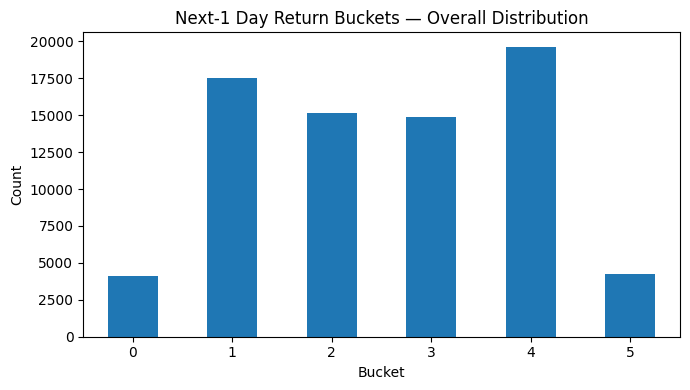

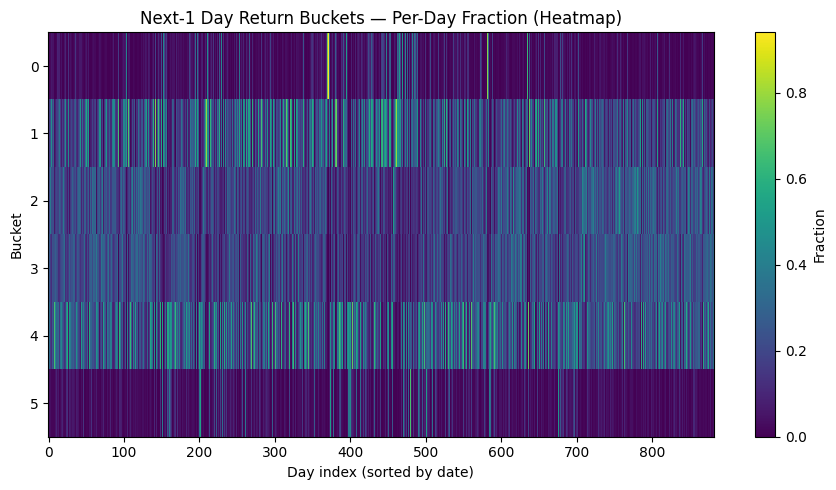

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

H = 1  # horizon in days

price_col = 'close_price' if 'close_price' in master_df.columns else 'close'
assert {'date','ticker',price_col}.issubset(master_df.columns), "master_df missing required columns."

df = master_df[['date','ticker',price_col]].copy()
df = df.sort_values(['ticker','date'])

# Forward return over H days: r_{t→t+H} = P_{t+H}/P_t - 1
df['ret_fwd'] = df.groupby('ticker')[price_col].transform(lambda s: s.shift(-H) / s - 1.0)

# Bucketise
df['bucket'] = pd.cut(df['ret_fwd'], bins=BUCKET_BINS, labels=BUCKET_LABEL_NAMES, include_lowest=True, right=True)

#overall distribution (all tickers, all days)
overall_counts = df['bucket'].value_counts(dropna=True).reindex(BUCKET_LABEL_NAMES).fillna(0).astype(int)
overall_frac = (overall_counts / overall_counts.sum()).round(4)
display(pd.DataFrame({'count': overall_counts, 'fraction': overall_frac}))

#Per-day distribution (counts)
per_day = (df.dropna(subset=['bucket'])
             .groupby(['date','bucket'])
             .size()
             .unstack(fill_value=0)
             .reindex(columns=BUCKET_LABEL_NAMES)
          )

plt.figure(figsize=(7,4))
overall_counts.plot(kind='bar')
plt.title(f"Next-{H} Day Return Buckets — Overall Distribution")
plt.ylabel("Count")
plt.xlabel("Bucket")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

per_day_frac = per_day.div(per_day.sum(axis=1), axis=0).fillna(0)

plt.figure(figsize=(9,5))
plt.imshow(per_day_frac.T, aspect='auto', interpolation='nearest')
plt.title(f"Next-{H} Day Return Buckets — Per-Day Fraction (Heatmap)")
plt.yticks(range(len(BUCKET_LABEL_NAMES)), BUCKET_LABEL_NAMES)
plt.xlabel("Day index (sorted by date)")
plt.ylabel("Bucket")
plt.colorbar(label="Fraction")
plt.tight_layout()
plt.show()
